# EKF SLAM for a Robot with a Range-Bearing Sensor

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
import timeit
import slam_utils as utils

def benchmark(func, runs=10):
    t = timeit.timeit(func, number=runs)
    return t / runs

In this example, we consider a differential drive robot with a range-bearing sensor that observes various landmarks in the environment. We will have the robot drive a square trajectory through the world, and then use EKF SLAM to estimate the trajectory driven by the robot.

The state of the differential drive robot consists of the two-dimensional pose (position and heading), $\textbf{x} = [x, y, \theta]^\top$.
The dynamics model is:
\begin{equation*}
\dot{x} = v\cos(\theta), \quad \dot{y} = v\sin(\theta), \quad \dot{\theta} = \omega,
\end{equation*}
where $v$ is the speed command and $\omega$ is the angular velocity command.


Suppose a sensor is available that measures the range, $r$, and bearing, $\phi$, to features $m_j \in \textbf{m}$ relative to the robot’s local frame. 
At each time step, multiple measurements are collected:
\begin{equation*}
\textbf{z}_t = \{[r_t^1,\phi_t^1]^\top , [r_t^2,\phi_t^2]^\top , \dots\},
\end{equation*}
where each measurement $\textbf{z}_t^i=[r_t^i,\phi_t^i]^\top$.

Below, we define the `Robot` class. This class defines the robot dynamics (computed using an exact discretization method) and the range-bearing sensor measurement model.

In [2]:
class Robot:
    """
    Differential drive robot with range-bearing sensor.
    """
    def __init__(
        self,
        control_cov: np.ndarray,
        range_bearing_cov: np.ndarray,
        sensor_range: float,
    ):
        """
        Args:
            control_cov: covariance matrix for control noise
            range_bearing_cov: covariance matrix for range-bearing measurement noise
            sensor_range: maximum sensing range for landmark observations
        """
        self.control_cov = control_cov
        self.range_bearing_cov = range_bearing_cov
        self.sensor_range = sensor_range
    
    def step(self, x: np.ndarray, u: np.ndarray, dt: float, add_noise: bool=True) -> np.ndarray:
        """
        Integrate differential drive model for dt seconds given the control input.

        Args:
            x: state vector, [px, py, th]
            u: control vector, [v, ω]
            dt: time step
            add_noise: whether to add control noise

        Returns:
            State after dt seconds.
        """
        px, py, th = x
        if add_noise:
            u = self.add_noise(u, self.control_cov)
        v, ω = u
        if abs(ω) < 1e-9:
            return np.array([px + v * dt * np.cos(th),
                             py + v * dt * np.sin(th),
                             th])

        # Compute turning radius
        r = v / ω

        # Compute change in angle over timestep
        dth = ω * dt

        # Compute center of rotation
        cx  = px - r * np.sin(th)
        cy  = py + r * np.cos(th)

        # Compute new angle and update position on circle
        th2 = th + dth
        px2  = cx + r * np.sin(th2)
        py2  = cy - r * np.cos(th2)
        return np.array([px2, py2, utils.wrap_angle(th2)])

    def add_noise(self, x: np.ndarray, cov: np.ndarray) -> np.ndarray:
        """
        Add noise to the input array given a covariance matrix.

        Args:
            x: array to add noise to, shape (n,)
            cov: covariance matrix for multivariate normal noise, shape (n,n)

        Returns:
            Array x with added noise.
        """
        return x + np.random.multivariate_normal(np.zeros(len(x)), cov)

    def range_bearing_measurement(
        self, 
        x: np.ndarray, 
        m: np.ndarray, 
        limit_range: bool=True, 
        add_noise: bool=True,
    ) -> [np.ndarray | None]:
        """
        Compute a noisy range-bearing measurement [r, b] given the robot's 
        current pose and the landmark position.

        Args:
            x: robot pose, [px, py, th]
            m: landmark position, [mx, my]
            limit_range: whether to limit range of sensor
            add_noise: whether to add noise

        Returns:
            Noisy range-bearing measurent, [r, b], if the landmark is within sensor range,
            otherwise returns None.
        """
        rel_pos = m - x[:2]
        r = np.linalg.norm(rel_pos)
        if r <= self.sensor_range or not limit_range:
            b = utils.wrap_angle(np.atan2(rel_pos[1], rel_pos[0]) - x[2])
            return self.add_noise(np.array([r, b]), self.range_bearing_cov) if add_noise else np.array([r, b])
        else:
            return None

# At each timestep the robot measures a different number of range-bearing
# measurements. Each element of a LandmarkMeas is a measurement of a single
# landmark, along with the landmark index (correspondence).
LandmarkMeas = List[Tuple[int, np.ndarray]]

def simulate(
    robot: Robot,
    world: utils.World,
    controls: np.ndarray,
    dt: float,
) -> tuple[np.ndarray, List[LandmarkMeas]]:
    """
    Simulate robot following open-loop control sequence while collecting 
    range-bearing measurements.

    Args:
        robot: robot to simulate
        world: world to simulate
        controls: open-loop sequence of controls, [u, ω], shape (T, 2)
        dt: timestep

    Returns:
        Ground-truth robot trajectory, shape (T + 1, 3)
        Landmark measurements, length T + 1
    """
    def landmark_measurements(x):
        measurements = []
        for j, m in enumerate(world.landmarks):
            z = robot.range_bearing_measurement(x, m)
            if z is not None:
                measurements.append((j, z))
        return measurements
        
    T = controls.shape[0]
    x = np.zeros((T + 1, 3))
    lm_meas = []
    for t in range(T):
        # Simulate robot
        x[t + 1] = robot.step(x[t], controls[t, :], dt)

        # Landmark range-bearing measurements
        lm_meas.append(landmark_measurements(x[t]))
        
    # Append last measurement
    lm_meas.append(landmark_measurements(x[-1]))

    return x, lm_meas

### Filter-based Approach: EKF SLAM
The EKF SLAM algorithm leverages the extended Kalman filter approach in the context of a SLAM problem to maintain a joint Gaussian over robot poses and landmarks.

In [3]:
class EKFSLAM:
    def __init__(self, robot: Robot, N: int):
        self.robot = robot
        self.n = 3 + 2 * N # state dimension
        self.have_lm = np.zeros(N, dtype=bool) # have we seen landmark yet

    def dynamics_jacobian(self, y: np.ndarray, u: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """
        Computes the Jacobians of the dynamics model with respect 
        to the SLAM state and robot input commands.
        
        Args:
            y: combined robot + landmark state, [x, y, θ, m_1x, m_1y, ...], size (self.n,)
            u: robot control vector [v, omega] where v is the
               linear velocity and omega is the angular velocity
        
        Returns:
            State Jacobian of the dynamics model, Gx, shape (self.n, self.n)
            Control Jacobian of the dynamics model, Gu, shape (self.n, 2) 
        """
        v, ω = u
        px, py, th = y[:3]
        if abs(ω) < 1e-9:
            Fx = np.array([[1, 0, -v * dt * np.sin(th)],
                           [0, 1,  v * dt * np.cos(th)],
                           [0, 0,  1]])
            Fu = np.array([[dt * np.cos(th), -0.5 * v * dt**2 * np.sin(th)],
                           [dt * np.sin(th), 0.5 * v * dt**2 * np.cos(th)],
                           [0, dt]])
        else:
            r = v / ω 
            dth = ω * dt
            th2 = th + dth
            Fx = np.array([[1, 0, -r * np.cos(th) + r * np.cos(th2)],
                           [0, 1, -r * np.sin(th) + r * np.sin(th2)],
                           [0, 0, 1]])
            Fu = np.zeros((3,2))
            Fu[0,0] = (np.sin(th2) - np.sin(th)) / ω
            Fu[1,0] = (-np.cos(th2) + np.cos(th)) / ω
            Fu[2,0] = 0
            Fu[0,1] = (v / (ω**2)) * (np.sin(th) - np.sin(th2)) + r * np.cos(th2) * dt
            Fu[1,1] = (v / (ω**2)) * (np.cos(th2) - np.cos(th)) + r * np.sin(th2) * dt
            Fu[2,1] = dt

        # Assemble into full state Jacobian
        Gx = np.eye(self.n)
        Gx[0:3, 0:3] = Fx
        
        Gu = np.zeros((self.n, 2))
        Gu[0:3, :] = Fu
        return Gx, Gu
    
    def measurement_jacobian(self, y: np.ndarray, j: int) -> np.ndarray:
        """
        Computes the Jacobian of the measurement model with respect
        to the SLAM state.
        
        Args:
            y: combined robot + landmark state, [x, y, θ, m_1x, m_1y, ...], size (n,)
            j: correspondence index for the landmark
        
        Returns:
            Jacobian of the measurement model, H, shape (2, self.n)
        """
        H = np.zeros((2, self.n))

        # Jacobian w.r.t. robot pose
        m_idx = 3 + 2 * j
        m = y[m_idx:m_idx + 2]
        dx = m[0] - y[0]
        dy = m[1] - y[1]
        r_sq = dx**2 + dy**2
        # r_sq = max(r_sq, 1e-6)
        r = np.sqrt(r_sq)
        H[:, :3] = np.array([[-dx / r, -dy / r, 0],
                             [dy / r_sq, -dx / r_sq,  -1]])

        # Jacobian w.r.t. landmark position
        H[0, m_idx]   =  dx / r
        H[0, m_idx + 1] =  dy / r
        H[1, m_idx]   = -dy / r_sq
        H[1, m_idx + 1] =  dx / r_sq

        return H

    def predict(self, prior_mean, prior_cov, u, dt):
        pred_mean = prior_mean.copy()
        pred_mean[:3] = robot.step(prior_mean[:3], u, dt, add_noise=False)
        Gx, Gu = self.dynamics_jacobian(prior_mean[:3], u)
        pred_cov = Gx @ prior_cov @ Gx.T + Gu @ self.robot.control_cov @ Gu.T
        return pred_mean, pred_cov

    def init_landmark(self, mean, cov, j, z):
        r, b = z
        x, y, th = mean[:3]
        lx = x + r * np.cos(b + th)
        ly = y + r * np.sin(b + th)
        m_idx = 3 + 2 * j
        mean[m_idx:m_idx + 2] = np.array([lx, ly])
        self.have_lm[j] = True
        cov[m_idx:m_idx + 2, m_idx:m_idx + 2] = np.diag([0.5, 0.5])

    def update(self, pred_mean, pred_cov, j, z):
        if not self.have_lm[j]:
            # Intialize landmark if its the first time we have seen it
            self.init_landmark(pred_mean, pred_cov, j, z)
        m_idx = 3 + 2 * j
        m = pred_mean[m_idx:m_idx + 2]

        # Update for the given landmark
        z_pred = robot.range_bearing_measurement(pred_mean, m, limit_range=False, add_noise=False)
        H = self.measurement_jacobian(pred_mean, j)
        S = H @ pred_cov @ H.T + robot.range_bearing_cov
        K = pred_cov @ H.T @ np.linalg.inv(S)
        residual = z - z_pred
        residual[1] = utils.wrap_angle(residual[1])

        mean = pred_mean + K @ residual
        mean[2] = utils.wrap_angle(mean[2])
        cov = (np.eye(self.n) - K @ H) @ pred_cov
        return mean, cov

def run_ekf_slam(
    robot: Robot, 
    world: utils.World, 
    controls: np.ndarray, 
    dt: float, 
    lm_meas: List[LandmarkMeas]):
    """
    Simulate robot following open-loop control sequence while collecting 
    odometry, range-bearing, and loop-closure measurements.

    Args:
        robot: robot to run EKF SLAM for
        world: world
        controls: open-loop sequence of controls, [u, ω], shape (T, 2)
        dt: timestep
        lm_meas: landmark measurements, length T + 1

    Returns:
        Estimated robot trajectory using EKF SLAM, shape (T + 1, 3)
    """
    ekf = EKFSLAM(robot, world.num_landmarks())

    # Initialize mean and covariance
    mean = np.zeros(ekf.n)
    cov = np.eye(ekf.n) * 1e6
    cov[:3, :3] = np.diag([1e-6, 1e-6, 1e-6])

    # Simulate EKF SLAM
    T = controls.shape[0]
    y_ekf = np.zeros((T + 1, ekf.n))
    for t in range(T):
        mean, cov = ekf.predict(mean, cov, controls[t, :], dt)
        for (j, z) in lm_meas[t + 1]:
            mean, cov = ekf.update(mean, cov, j, z)
        y_ekf[t + 1] = mean.copy()
    return y_ekf

### Run EKF SLAM
Run the code below to run the EKF Slam algorithm. Try playing around with the covariances and the range of the sensor to see how that impacts the resulting SLAM solution.

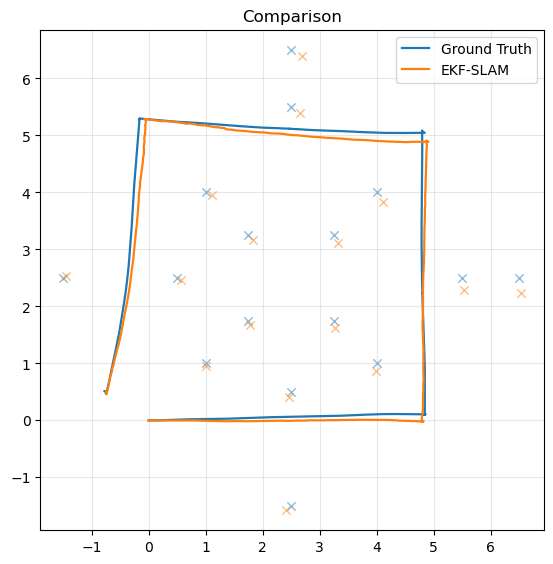

=== Error metric and execution time ===
EKF-SLAM           : 0.124 m, time: 0.00 ms


In [4]:
# Create simple world
world = utils.make_simple_world()

# Define robot and the various covariances for its measurements
control_cov = np.diag([0.1**2, (np.deg2rad(3.0))**2])     # control noise (v,w)
sensor_range = 0.4 * (np.sqrt(2) * world.side_length)  # see many LMs on each side
range_bearing_cov = np.diag([0.20**2, (np.deg2rad(2.0))**2])
robot = Robot(control_cov=control_cov,
              range_bearing_cov=range_bearing_cov, 
              sensor_range=sensor_range)

# Simulate a square trajectory and compute simulated measurements
dt = 0.1
controls = utils.square_loop_control_sequence(world, v=0.25, dt=dt)
np.random.seed(3)  # stable example
x_gt, lm_meas = simulate(robot, world, controls, dt)

# Run EKF SLAM and compare results
y_ekf = run_ekf_slam(robot, world, controls, dt, lm_meas)
time_ekf = 0

# Uncomment the line below to try timing the EKF
# time_ekf = benchmark(lambda: run_ekf_slam(robot, world, controls, dt, lm_meas))

# Parse data
x_ekf = y_ekf[:, :3]
n_landmarks = int(y_ekf[-1, 3:].shape[0] / 2)
lm_ekf = y_ekf[-1, 3:].reshape(n_landmarks, 2)
world_ekf = utils.World(landmarks=lm_ekf, side_length=world.side_length)

# Plot
utils.plot_traj("Comparison", {"Ground Truth": x_gt, "EKF-SLAM": x_ekf}, [world, world_ekf])
rmse_ekf = utils.absolute_trajectory_rmse(x_gt, x_ekf)
print("=== Error metric and execution time ===")
print(f"EKF-SLAM           : {rmse_ekf:.3f} m, time: {1000*time_ekf:.2f} ms")